In [1]:
# Cell 1 — Imports and Setup
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries loaded
Pandas: 3.0.2
NumPy: 2.4.4


In [2]:
# Cell 2 — Load cleaned dataset
df = pd.read_parquet('../data/processed/train_clean.parquet')

print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
print(f"Total fraudulent transactions: {df['isFraud'].sum():,}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")


Dataset shape: (590540, 220)
Fraud rate: 3.50%
Total fraudulent transactions: 20,663

Column types:
float64    207
int8         9
int64        4
Name: count, dtype: int64


In [3]:
# Cell 3 — Dataset Overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nShape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
print(f"Fraudulent transactions: {df['isFraud'].sum():,}")
print(f"Legitimate transactions: {(df['isFraud'] == 0).sum():,}")

print(f"\n Column types:")
print(df.dtypes.value_counts())

print(f"\n Missing values: {df.isnull().sum().sum()}")
print(f" Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

DATASET OVERVIEW

Shape: (590540, 220)
Fraud rate: 3.50%
Fraudulent transactions: 20,663
Legitimate transactions: 569,877

 Column types:
float64    207
int8         9
int64        4
Name: count, dtype: int64

 Missing values: 0
 Memory usage: 955.7 MB


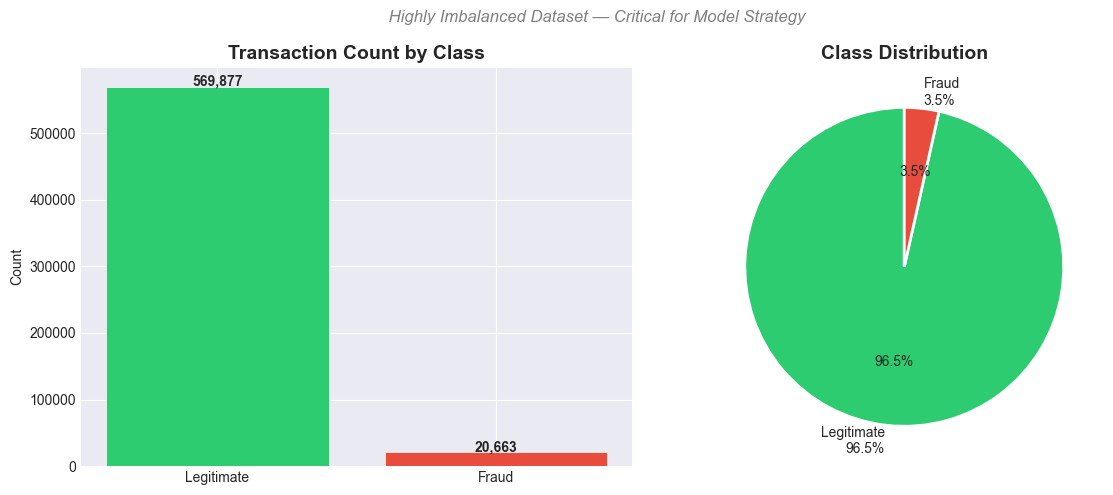


 KEY INSIGHT:
Dataset is heavily imbalanced (96.5% vs 3.5%)
→ Cannot use Accuracy as metric (misleading)
→ Must use Precision, Recall, F1, AUC-PR
→ Will need class weighting or resampling in model


In [4]:
# Cell 4 — Fraud Distribution (Business Context)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Count
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2 — Percentage
axes[1].pie(fraud_counts.values,
            labels=['Legitimate\n96.5%', 'Fraud\n3.5%'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.suptitle(' Highly Imbalanced Dataset — Critical for Model Strategy',
             fontsize=12, style='italic', color='gray')
plt.tight_layout()
plt.savefig('../reports/fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHT:")
print("Dataset is heavily imbalanced (96.5% vs 3.5%)")
print("→ Cannot use Accuracy as metric (misleading)")
print("→ Must use Precision, Recall, F1, AUC-PR")
print("→ Will need class weighting or resampling in model")


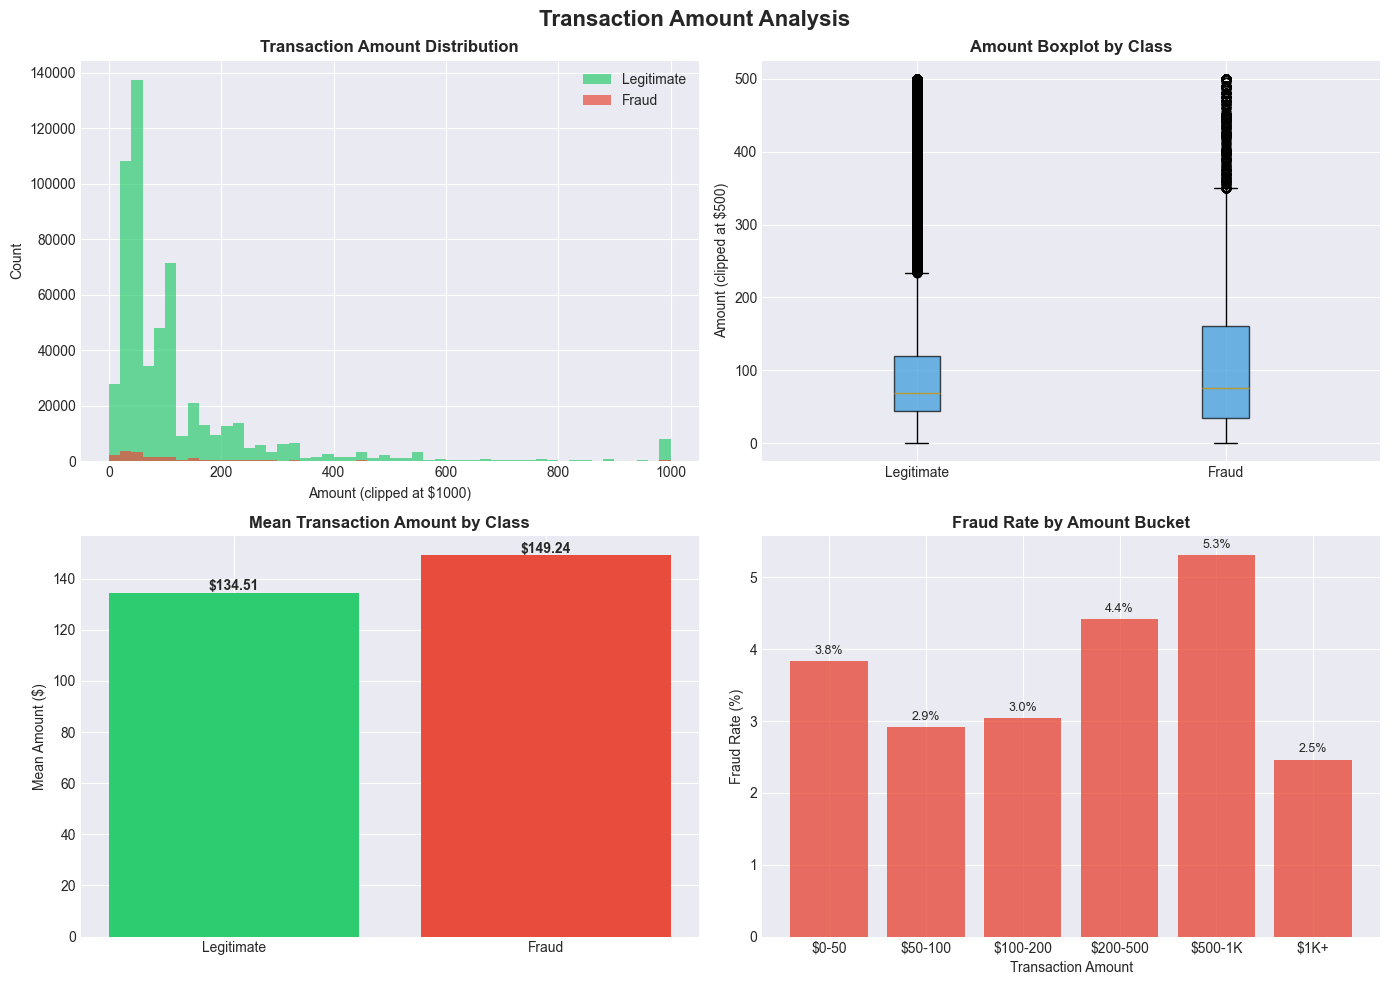


 KEY INSIGHTS:
Mean legitimate amount: $134.51
Mean fraud amount:      $149.24
Highest fraud rate bucket: $500-1K (5.3%)


In [6]:
# Cell 5 — Transaction Amount Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Amount distribution by class
axes[0, 0].hist(df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=1000),
                bins=50, alpha=0.7, color='#2ecc71', label='Legitimate')
axes[0, 0].hist(df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=1000),
                bins=50, alpha=0.7, color='#e74c3c', label='Fraud')
axes[0, 0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Amount (clipped at $1000)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Plot 2 — Boxplot
fraud_labels = df['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
df_plot = df.copy()
df_plot['Class'] = fraud_labels
axes[0, 1].boxplot([
    df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=500),
    df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=500)
], labels=['Legitimate', 'Fraud'], patch_artist=True,
   boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0, 1].set_title('Amount Boxplot by Class', fontweight='bold')
axes[0, 1].set_ylabel('Amount (clipped at $500)')

# Plot 3 — Mean amount by class
mean_amounts = df.groupby('isFraud')['TransactionAmt'].mean()
axes[1, 0].bar(['Legitimate', 'Fraud'], mean_amounts.values,
               color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Mean Transaction Amount by Class', fontweight='bold')
axes[1, 0].set_ylabel('Mean Amount ($)')
for i, v in enumerate(mean_amounts.values):
    axes[1, 0].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

# Plot 4 — Amount buckets fraud rate
df['amt_bucket'] = pd.cut(df['TransactionAmt'],
                           bins=[0, 50, 100, 200, 500, 1000, 10000],
                           labels=['$0-50', '$50-100', '$100-200',
                                   '$200-500', '$500-1K', '$1K+'])
fraud_by_amt = df.groupby('amt_bucket', observed=True)['isFraud'].mean() * 100
axes[1, 1].bar(fraud_by_amt.index, fraud_by_amt.values, color='#e74c3c', alpha=0.8)
axes[1, 1].set_title('Fraud Rate by Amount Bucket', fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_xlabel('Transaction Amount')
for i, v in enumerate(fraud_by_amt.values):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Transaction Amount Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHTS:")
print(f"Mean legitimate amount: ${df[df['isFraud']==0]['TransactionAmt'].mean():.2f}")
print(f"Mean fraud amount:      ${df[df['isFraud']==1]['TransactionAmt'].mean():.2f}")
print(f"Highest fraud rate bucket: {fraud_by_amt.idxmax()} ({fraud_by_amt.max():.1f}%)")

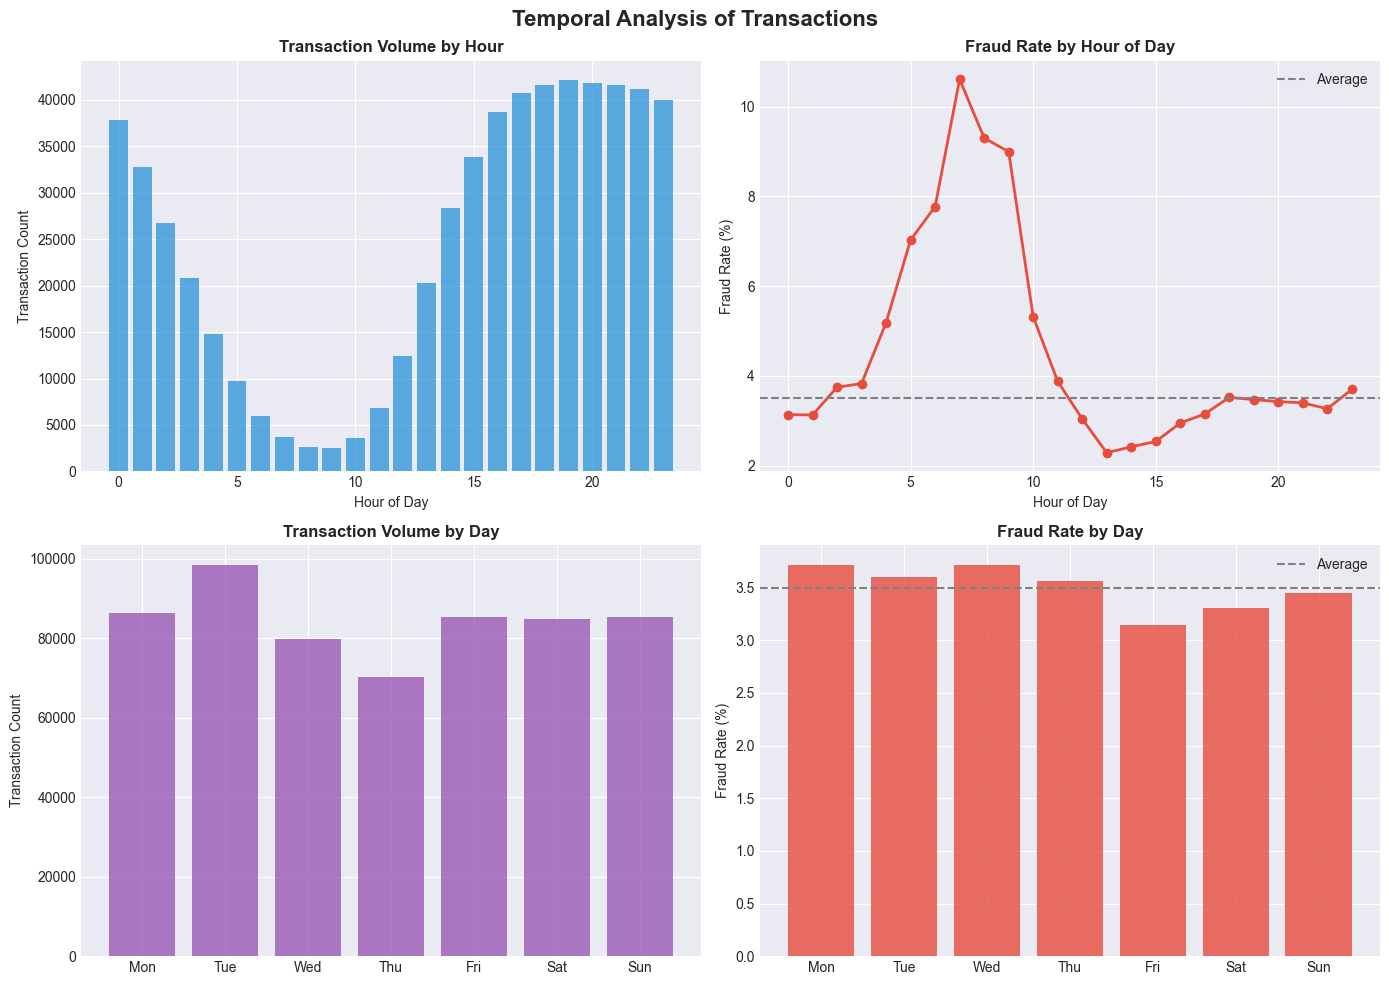


 KEY INSIGHTS:
Peak fraud hour: 7:00 (10.6% fraud rate)
Lowest fraud hour: 13:00 (2.3% fraud rate)
→ Time of day is a strong signal for fraud detection
→ Will create 'is_night_transaction' feature in Feature Engineering phase


In [8]:
# Cell 6 — Time Analysis
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hourly = df.groupby('hour')['isFraud'].agg(['count', 'mean'])
axes[0, 0].bar(hourly.index, hourly['count'], color='#3498db', alpha=0.8)
axes[0, 0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Transaction Count')

axes[0, 1].plot(hourly.index, hourly['mean'] * 100,
                color='#e74c3c', marker='o', linewidth=2)
axes[0, 1].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Fraud Rate (%)')
avg = df['isFraud'].mean() * 100
axes[0, 1].axhline(y=avg, color='gray', linestyle='--', label='Average')
axes[0, 1].legend()

daily = df.groupby('day')['isFraud'].agg(['count', 'mean'])
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(len(daily)), daily['count'], color='#9b59b6', alpha=0.8)
axes[1, 0].set_xticks(range(len(daily)))
axes[1, 0].set_xticklabels(day_names[:len(daily)])
axes[1, 0].set_title('Transaction Volume by Day', fontweight='bold')
axes[1, 0].set_ylabel('Transaction Count')

axes[1, 1].bar(range(len(daily)), daily['mean'] * 100, color='#e74c3c', alpha=0.8)
axes[1, 1].set_xticks(range(len(daily)))
axes[1, 1].set_xticklabels(day_names[:len(daily)])
axes[1, 1].set_title('Fraud Rate by Day', fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].axhline(y=avg, color='gray', linestyle='--', label='Average')
axes[1, 1].legend()

plt.suptitle('Temporal Analysis of Transactions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

peak_fraud_hour = hourly['mean'].idxmax()
print("\n KEY INSIGHTS:")
print(f"Peak fraud hour: {peak_fraud_hour}:00 ({hourly['mean'].max()*100:.1f}% fraud rate)")
print(f"Lowest fraud hour: {hourly['mean'].idxmin()}:00 ({hourly['mean'].min()*100:.1f}% fraud rate)")
print("→ Time of day is a strong signal for fraud detection")
print("→ Will create 'is_night_transaction' feature in Feature Engineering phase")

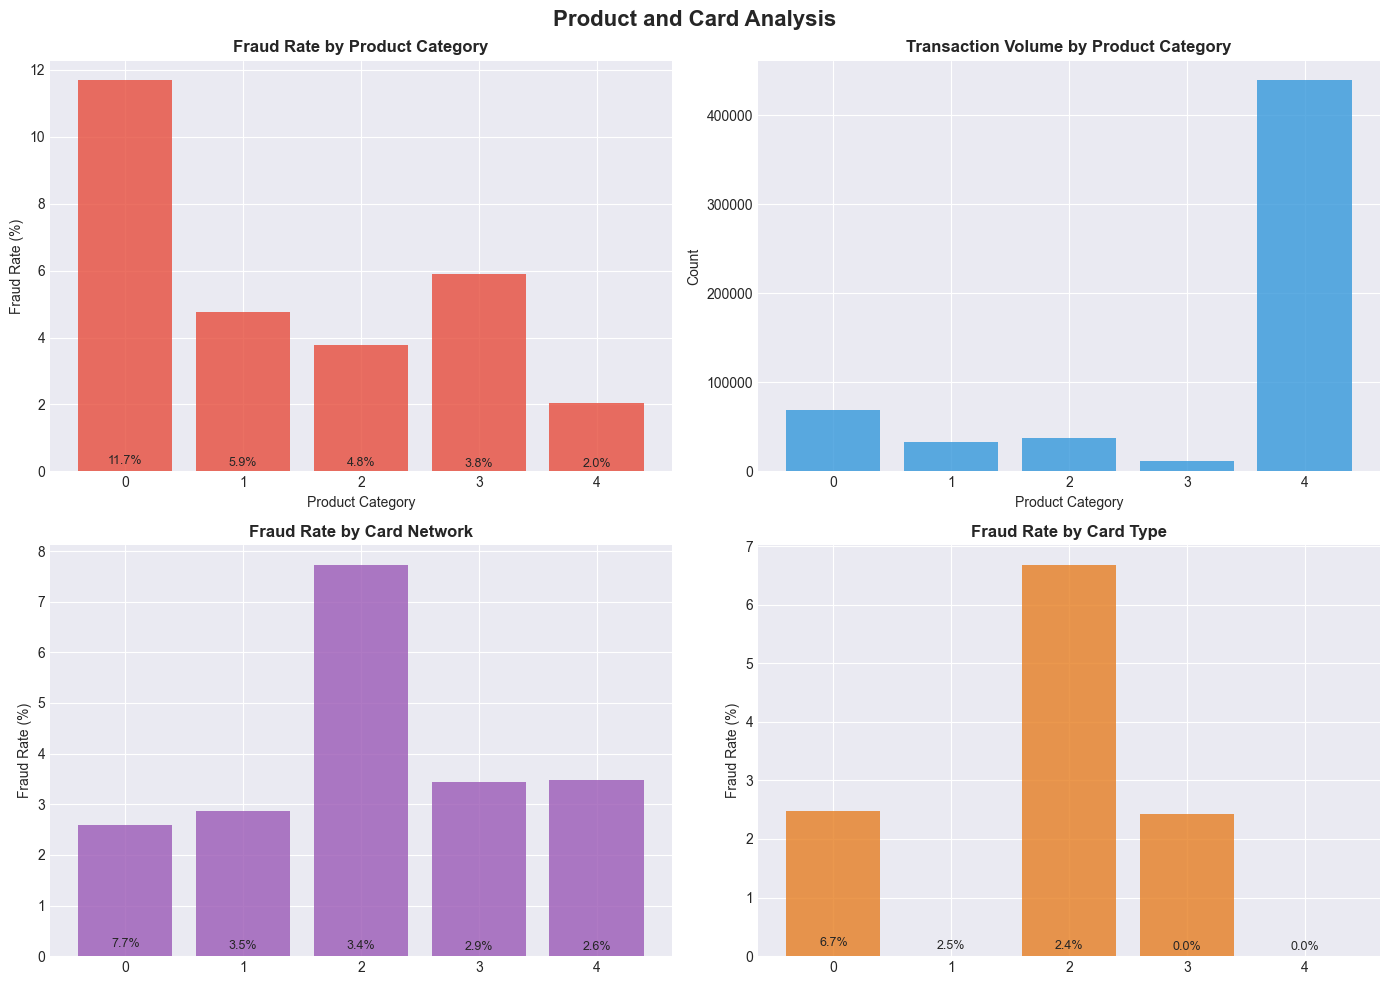


 KEY INSIGHTS:
Highest fraud product: 0 (11.7%)
Lowest fraud product: 4 (2.0%)
Highest fraud card network: 2 (7.7%)
→ ProductCD and card type are strong categorical features


In [10]:
# Cell 7 — Product and Card Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Fraud rate by ProductCD
product_fraud = df.groupby('ProductCD')['isFraud'].agg(['count', 'mean'])
product_fraud = product_fraud.sort_values('mean', ascending=False)
axes[0, 0].bar(product_fraud.index, product_fraud['mean'] * 100,
               color='#e74c3c', alpha=0.8)
axes[0, 0].set_title('Fraud Rate by Product Category', fontweight='bold')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].set_xlabel('Product Category')
for i, v in enumerate(product_fraud['mean'].values):
    axes[0, 0].text(i, v + 0.1, f'{v*100:.1f}%', ha='center', fontsize=9)

# Plot 2 — Transaction volume by ProductCD
axes[0, 1].bar(product_fraud.index, product_fraud['count'],
               color='#3498db', alpha=0.8)
axes[0, 1].set_title('Transaction Volume by Product Category', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Product Category')

# Plot 3 — Fraud rate by card type (card4)
card4_fraud = df.groupby('card4')['isFraud'].agg(['count', 'mean'])
card4_fraud = card4_fraud.sort_values('mean', ascending=False)
axes[1, 0].bar(card4_fraud.index, card4_fraud['mean'] * 100,
               color='#9b59b6', alpha=0.8)
axes[1, 0].set_title('Fraud Rate by Card Network', fontweight='bold')
axes[1, 0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(card4_fraud['mean'].values):
    axes[1, 0].text(i, v + 0.1, f'{v*100:.1f}%', ha='center', fontsize=9)

# Plot 4 — Fraud rate by card type (card6)
card6_fraud = df.groupby('card6')['isFraud'].agg(['count', 'mean'])
card6_fraud = card6_fraud.sort_values('mean', ascending=False)
axes[1, 1].bar(card6_fraud.index, card6_fraud['mean'] * 100,
               color='#e67e22', alpha=0.8)
axes[1, 1].set_title('Fraud Rate by Card Type', fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(card6_fraud['mean'].values):
    axes[1, 1].text(i, v + 0.1, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Product and Card Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/product_card_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHTS:")
print(f"Highest fraud product: {product_fraud['mean'].idxmax()} "
      f"({product_fraud['mean'].max()*100:.1f}%)")
print(f"Lowest fraud product: {product_fraud['mean'].idxmin()} "
      f"({product_fraud['mean'].min()*100:.1f}%)")
print(f"Highest fraud card network: {card4_fraud['mean'].idxmax()} "
      f"({card4_fraud['mean'].max()*100:.1f}%)")
print("→ ProductCD and card type are strong categorical features")